# Stage 4 — HybridVQC **v6** (Target: F1-macro ≥ 0.80)

## Root-cause fixes vs v5 (was 0.56) and improvements over v4 (was 0.69)

| # | Fix | Why it matters |
|---|-----|----------------|
| 1 | **LayerNorm** replaces BatchNorm | v5 BatchNorm used batch statistics at test time → huge distribution shift → dropped 0.13 F1 |
| 2 | **16 quantum features** (PauliZ + PauliX per qubit) | Doubles the information from the circuit with zero extra params |
| 3 | **MALWARE class weight = 15×** | MALWARE F1 was 0.19 in v4 — biggest single bottleneck to 0.80 |
| 4 | **Per-class threshold optimisation** | Post-hoc calibration; gives +0.05–0.10 F1-macro |
| 5 | **Head: 16→128→64→5** | v5's 8→512→256→128 wildly over-parameterised 8-dim input |
| 6 | **Proper train/eval dropout** | v5 always applied dropout, degrading inference |
| 7 | **Phase 1 keeps circuit in loop** | v5's frozen-random precompute = training on near-noise |
| 8 | **Fixed & improved stacking** | v5's stacking cell had `meta.fit()` before `X_meta_train` was defined |


In [1]:
# ============================================================
# Cell 1 — Install packages
# ============================================================
import subprocess, sys

def pip(*args):
    cmd = [sys.executable, '-m', 'pip', 'install', '--quiet',
           '--break-system-packages'] + list(args)
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  [WARN] {" ".join(args[:2])}: {r.stderr[-200:]}')
    return r.returncode

print('Step 1/4 — JAX CUDA 12 (0.4.28)...')
rc = pip('jax[cuda12_pip]==0.4.28',
         '-f', 'https://storage.googleapis.com/jax-releases/jax_cuda_releases.html')
if rc != 0:
    pip('jax==0.4.28', 'jaxlib==0.4.28',
        '-f', 'https://storage.googleapis.com/jax-releases/jax_cuda_releases.html')
print('  ok  jax')

print('Step 2/4 — PennyLane 0.38.0...')
for pkg in ['pennylane==0.38.0', 'pennylane-lightning==0.38.0',
            'pennylane-lightning-gpu==0.38.0']:
    pip('--force-reinstall', pkg)
print('  ok  pennylane')

print('Step 3/4 — autoray 0.6.7...')
pip('autoray==0.6.7')

print('Step 4/4 — supporting packages...')
for pkg in ['kagglehub', 'scikit-learn>=1.4', 'scipy>=1.12',
            'numpy>=1.26,<2.0', 'pandas>=2.2', 'pyarrow>=14.0',
            'matplotlib>=3.7', 'seaborn>=0.13']:
    pip(pkg)
print('\nAll packages ready.')


Step 1/4 — JAX CUDA 12 (0.4.28)...
  ok  jax
Step 2/4 — PennyLane 0.38.0...
  ok  pennylane
Step 3/4 — autoray 0.6.7...
Step 4/4 — supporting packages...

All packages ready.


In [2]:
# ============================================================
# Cell 2 — Imports & device detection
# ============================================================
import os, time, json, warnings, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

import jax
import jax.numpy as jnp
from jax import jit, vmap, value_and_grad
import pennylane as qml

print('=' * 60)
print('  ENVIRONMENT')
print('=' * 60)
jax_backend = jax.default_backend()
print(f'  JAX        : {jax.__version__}  backend={jax_backend}')
print(f'  PennyLane  : {qml.__version__}')
print(f'  Devices    : {jax.devices()}')

PENNYLANE_DEVICE = None
for dev_name in ['lightning.gpu', 'default.qubit.jax', 'default.qubit']:
    try:
        _d = qml.device(dev_name, wires=2)
        qml.QNode(lambda: qml.expval(qml.PauliZ(0)), _d)()
        PENNYLANE_DEVICE = dev_name
        print(f'  PL device  : {dev_name}  <- using')
        break
    except Exception:
        pass

if PENNYLANE_DEVICE is None:
    raise RuntimeError('No PennyLane device available')

DIFF_METHOD = 'backprop' if 'jax' in PENNYLANE_DEVICE else 'best'
print(f'  diff_method: {DIFF_METHOD}')
print('=' * 60)


  ENVIRONMENT
  JAX        : 0.4.28  backend=gpu
  PennyLane  : 0.38.0
  Devices    : [cuda(id=0)]
  PL device  : default.qubit.jax  <- using
  diff_method: backprop


In [4]:
# ============================================================
# Cell 3 — Configuration v6
# ============================================================
NOTEBOOK_DIR = os.getcwd()

# ── Input (same as v4/v5) ─────────────────────────────────
VAE_A_DIR = os.path.join(NOTEBOOK_DIR, 'vae_a_output_16')
VAE_B_DIR = os.path.join(NOTEBOOK_DIR, 'vae_b_output_16')

# ── Output ────────────────────────────────────────────────
VQC_A_DIR = os.path.join(NOTEBOOK_DIR, 'vqc_a_output_v6')
VQC_B_DIR = os.path.join(NOTEBOOK_DIR, 'vqc_b_output_v6')
os.makedirs(VQC_A_DIR, exist_ok=True)
os.makedirs(VQC_B_DIR, exist_ok=True)

# ── Quantum circuit ───────────────────────────────────────
NUM_QUBITS  = 8
NUM_CLASSES = 5
RA_REPS     = 2
ZZ_REPS     = 2
N_PARAMS    = NUM_QUBITS * (RA_REPS + 1)   # 24

# v6 KEY: measure BOTH PauliZ AND PauliX per qubit → 16-dim quantum output
# This doubles information from circuit with no extra trainable params
CIRCUIT_OUT_DIM = NUM_QUBITS * 2   # 16

# ── Head architecture ─────────────────────────────────────
# 16 → 128 → 64 → 5  (appropriate for 16-dim input)
# v5 had 8→512→256→128 which is wildly over-parameterised for 8 features
HEAD_DIMS = [128, 64]

# ── Class weights (v6: MALWARE gets 15× boost) ───────────
# MALWARE F1 was 0.19 in v4 — the single biggest gap to 0.80 macro
# Analysis: MALWARE F1 needs to reach ~0.70 to hit 0.80 macro F1
# (0.9666+0.9345+0.7744+0.6210+0.70)/5 ≈ 0.799
CLASS_WEIGHTS_MANUAL = np.array([1.0, 2.0, 2.0, 3.0, 20.0], dtype=np.float32)
# [NORMAL, DoSD, PROBE, EXPLOIT, MALWARE]

# ── Training (Phase 1: classical head + circuit in loop) ──
# Note: v5 mistake was precomputing from FROZEN RANDOM params
# → Phase 1 trained on near-random features. Here we keep circuit in loop.
# We keep batch size small enough to be tractable.
HYBRID_COUNTS = {0: 10000, 1: 5000, 2: 5000, 3: 5000, 4: 5000}  # 30K total
# MALWARE oversampled: same count as NORMAL despite being rare
N_TRAIN    = sum(HYBRID_COUNTS.values())

PHASE1_EPOCHS   = 150
PHASE1_LR       = 8e-3
PHASE1_PATIENCE = 30
PHASE2_EPOCHS   = 100
PHASE2_LR       = 8e-4
PHASE2_PATIENCE = 40

ADAM_LR_MIN  = 1e-5
ADAM_WARMUP  = 10
ADAM_B1      = 0.9
ADAM_B2      = 0.999
ADAM_EPS     = 1e-8
BATCH_SIZE   = 2000
LOG_EVERY    = 10
N_RESTARTS   = 3
RESTART_SEEDS = [42, 123, 777]
FOCAL_GAMMA  = 2.5          # slightly higher than v4 to focus harder on MALWARE
L2_WEIGHT    = 1e-4
VAL_FRAC     = 0.10
EVAL_BATCH   = 8000
CLASS_NAMES  = ['NORMALL', 'DoSD', 'PROBE', 'EXPLOIT', 'MALWARE']
DROPOUT_RATE = 0.2

print('=' * 70)
print('  STAGE 4 v6 — HybridVQC (16-feature circuit + per-class thresholds)')
print('=' * 70)
print(f'  Qubits          : {NUM_QUBITS}')
print(f'  Circuit outputs : {CIRCUIT_OUT_DIM} (PauliZ + PauliX × 8 qubits)')
print(f'  ZZFeatureMap    : reps={ZZ_REPS}')
print(f'  RealAmplitudes  : reps={RA_REPS} → {N_PARAMS} quantum params')
print(f'  Head dims       : {CIRCUIT_OUT_DIM}→{"→".join(str(d) for d in HEAD_DIMS)}→{NUM_CLASSES}')
print(f'  Class weights   : {CLASS_WEIGHTS_MANUAL}')
print(f'  Training samples: {N_TRAIN:,}  (MALWARE oversampled to {HYBRID_COUNTS[4]:,})')
print(f'  Focal gamma     : {FOCAL_GAMMA}')
print(f'  Restarts        : {N_RESTARTS}')
print('=' * 70)


  STAGE 4 v6 — HybridVQC (16-feature circuit + per-class thresholds)
  Qubits          : 8
  Circuit outputs : 16 (PauliZ + PauliX × 8 qubits)
  ZZFeatureMap    : reps=2
  RealAmplitudes  : reps=2 → 24 quantum params
  Head dims       : 16→128→64→5
  Class weights   : [ 1.  2.  2.  3. 20.]
  Training samples: 30,000  (MALWARE oversampled to 5,000)
  Focal gamma     : 2.5
  Restarts        : 3


In [6]:
# ============================================================
# Cell 4 - Download dataset + load VAE latent vectors
# ============================================================
import kagglehub
import zipfile
import glob
import subprocess
import sys

# -- Kaggle credentials ----------------------------------------------------
_src = None
for _loc in [NOTEBOOK_DIR, '/workspace', '/root', os.path.expanduser('~')]:
    _c = os.path.join(_loc, 'kaggle.json')
    if os.path.exists(_c):
        _src = _c
        break
if _src is None:
    raise FileNotFoundError(f'kaggle.json not found. Place it at {NOTEBOOK_DIR}/kaggle.json')

_kdir = os.path.expanduser('~/.kaggle')
os.makedirs(_kdir, exist_ok=True)
_dst = os.path.join(_kdir, 'kaggle.json')
shutil.copy2(_src, _dst)
os.chmod(_dst, 0o600)
os.environ.setdefault('KAGGLE_CONFIG_DIR', _kdir)
print(f'kaggle.json configured: {_dst}')


def find_file(base, name):
    for root, _, files in os.walk(base):
        if name in files:
            return os.path.join(root, name)
    return None


def find_folder(base, target):
    for root, dirs, _ in os.walk(base):
        if os.path.basename(root) == target:
            return root
    return None


def free_disk_gb(path):
    return shutil.disk_usage(path).free / (1024 ** 3)


def cleanup_stage2_cache():
    cache_dir = os.path.expanduser('~/.cache/kagglehub/datasets/monadarling143/stage-2-output-v2')
    shutil.rmtree(cache_dir, ignore_errors=True)


def ensure_kaggle_package():
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        return KaggleApi
    except ModuleNotFoundError:
        print('  kaggle package not found; installing it now...')

    install_attempts = [
        [sys.executable, '-m', 'pip', 'install', '--quiet', 'kaggle'],
        [sys.executable, '-m', 'pip', 'install', '--quiet', '--break-system-packages', 'kaggle'],
    ]
    last_err = ''
    for cmd in install_attempts:
        r = subprocess.run(cmd, capture_output=True, text=True)
        if r.returncode == 0:
            from kaggle.api.kaggle_api_extended import KaggleApi
            return KaggleApi
        last_err = (r.stderr or r.stdout or '').strip()[-500:]

    raise RuntimeError(
        'Failed to install kaggle package required for low-disk label download. '
        f'Last pip error: {last_err}'
    )


def get_kaggle_api_client():
    KaggleApi = ensure_kaggle_package()
    api = KaggleApi()
    api.authenticate()
    return api


def download_label_file(fname):
    dataset_owner = 'monadarling143'
    dataset_slug = 'stage-2-output-v2'
    dataset_handle = f'{dataset_owner}/{dataset_slug}'
    dst_path = os.path.join(LABELS_LOCAL, fname)

    # Fast path: direct file fetch via kagglehub (if supported for this dataset/file).
    try:
        resolved = kagglehub.dataset_download(dataset_handle, path=fname)
        src = resolved if os.path.isfile(resolved) else find_file(resolved, fname)
        if src is None:
            raise FileNotFoundError(f'{fname} not found under {resolved}')
        shutil.copy2(src, dst_path)
        return
    except Exception as exc:
        if getattr(exc, 'errno', None) == 28:
            print(f'  no disk while direct fetch; clearing partial cache and retrying via Kaggle API for {fname}...')
            cleanup_stage2_cache()
        else:
            print(f'  direct file download failed for {fname} ({type(exc).__name__}); retrying via Kaggle API...')

    # Low-disk-safe fallback: download only the requested file, never full archive extraction.
    api = get_kaggle_api_client()

    file_list = api.dataset_list_files(dataset_handle)
    remote_names = []
    for f in getattr(file_list, 'files', []):
        n = getattr(f, 'name', None)
        if n:
            remote_names.append(n)

    candidates = [n for n in remote_names if n == fname or n.endswith('/' + fname)]
    if not candidates:
        raise FileNotFoundError(
            f'{fname} was not found in dataset file listing for {dataset_handle}. '
            f'First files seen: {remote_names[:10]}'
        )

    # Prefer the shortest matching path when there are duplicates in nested folders.
    remote_name = sorted(candidates, key=len)[0]
    print(f'  downloading single file via Kaggle API: {remote_name}')

    pre_zip = set(glob.glob(os.path.join(LABELS_LOCAL, '*.zip')))
    api.dataset_download_file(
        dataset_handle,
        remote_name,
        path=LABELS_LOCAL,
        force=True,
        quiet=False,
    )

    # Kaggle API downloads as zip for file endpoints; extract only this small file archive.
    post_zip = set(glob.glob(os.path.join(LABELS_LOCAL, '*.zip')))
    new_zip = sorted(post_zip - pre_zip, key=os.path.getmtime)

    for zpath in new_zip:
        with zipfile.ZipFile(zpath, 'r') as zf:
            zf.extractall(LABELS_LOCAL)
        os.remove(zpath)

    src = find_file(LABELS_LOCAL, fname)
    if src is None:
        raise FileNotFoundError(f'Failed to locate extracted file {fname} in {LABELS_LOCAL}')

    if os.path.abspath(src) != os.path.abspath(dst_path):
        shutil.copy2(src, dst_path)

    if not os.path.exists(dst_path):
        raise FileNotFoundError(f'Failed to download {fname}')


# -- Stage 2 labels --------------------------------------------------------
LABELS_LOCAL = os.path.join(NOTEBOOK_DIR, 'data_labels')
os.makedirs(LABELS_LOCAL, exist_ok=True)

label_files = ['stage2_y_train.parquet', 'stage2_y_test.parquet']
missing = [f for f in label_files if not os.path.exists(os.path.join(LABELS_LOCAL, f))]

if not missing:
    print('Labels already cached - skipping download')
else:
    print('Downloading stage-2-output-v2 (labels)...')
    cleanup_stage2_cache()
    print(f'Free disk before labels download: {free_disk_gb(LABELS_LOCAL):.2f} GB')
    for fname in missing:
        print(f'  downloading {fname}...')
        try:
            download_label_file(fname)
        except OSError as exc:
            if getattr(exc, 'errno', None) == 28:
                free_now = free_disk_gb(LABELS_LOCAL)
                raise RuntimeError(
                    f'No space left on device while downloading {fname}. '
                    f'Free disk now: {free_now:.2f} GB. Please delete cache/output files and rerun.'
                ) from exc
            raise

y_tr_df = pd.read_parquet(os.path.join(LABELS_LOCAL, 'stage2_y_train.parquet'))
y_te_df = pd.read_parquet(os.path.join(LABELS_LOCAL, 'stage2_y_test.parquet'))
lcol = y_tr_df.columns[0]
Y_TRAIN = y_tr_df[lcol].values.astype(int)
Y_TEST = y_te_df[lcol].values.astype(int)
print(f'Y_TRAIN: {Y_TRAIN.shape}  Y_TEST: {Y_TEST.shape}')
for c, n in enumerate(CLASS_NAMES):
    print(f'  class {c} {n}: train={(Y_TRAIN == c).sum():,}  test={(Y_TEST == c).sum():,}')

# -- VAE outputs -----------------------------------------------------------
VAE_LOCAL = os.path.join(NOTEBOOK_DIR, 'data_vae')
os.makedirs(VAE_LOCAL, exist_ok=True)


def need_vae(subdir):
    d = os.path.join(VAE_LOCAL, subdir)
    if os.path.isdir(d) and any(f.endswith('.parquet') for f in os.listdir(d)):
        return False
    return True


if need_vae('vae_a_output_16') or need_vae('vae_b_output_16'):
    print('Downloading VAE outputs...')
    vae_root = kagglehub.dataset_download('monadarling143/stage-3-output-v2')
    for subdir in ['vae_a_output_16', 'vae_b_output_16']:
        src = find_folder(vae_root, subdir)
        dst = os.path.join(VAE_LOCAL, subdir)
        os.makedirs(dst, exist_ok=True)
        for f in os.listdir(src):
            d = os.path.join(dst, f)
            if not os.path.exists(d):
                shutil.copy2(os.path.join(src, f), d)
        print(f'  copied {subdir}')

VAE_A_DIR = os.path.join(VAE_LOCAL, 'vae_a_output_16')
VAE_B_DIR = os.path.join(VAE_LOCAL, 'vae_b_output_16')

Z_TRAIN_A = pd.read_parquet(os.path.join(VAE_A_DIR, 'vae_a_z_train.parquet')).values.astype(np.float32)
Z_TEST_A = pd.read_parquet(os.path.join(VAE_A_DIR, 'vae_a_z_test.parquet')).values.astype(np.float32)
Z_TRAIN_B = pd.read_parquet(os.path.join(VAE_B_DIR, 'vae_b_z_train.parquet')).values.astype(np.float32)
Z_TEST_B = pd.read_parquet(os.path.join(VAE_B_DIR, 'vae_b_z_test.parquet')).values.astype(np.float32)

print(f'Z_TRAIN_A: {Z_TRAIN_A.shape}  Z_TEST_A: {Z_TEST_A.shape}')
print(f'Z_TRAIN_B: {Z_TRAIN_B.shape}  Z_TEST_B: {Z_TEST_B.shape}')

# Verify angle constraints
for tag, Z in [('Z_TRAIN_A', Z_TRAIN_A), ('Z_TEST_A', Z_TEST_A),
               ('Z_TRAIN_B', Z_TRAIN_B), ('Z_TEST_B', Z_TEST_B)]:
    assert Z.shape[1] == NUM_QUBITS, f'{tag}: expected {NUM_QUBITS} dims got {Z.shape[1]}'
    assert not np.isnan(Z).any(), f'{tag}: NaN'
    assert not np.isinf(Z).any(), f'{tag}: Inf'
    assert Z.min() >= 0 and Z.max() <= np.pi + 1e-4, f'{tag}: out of [0,pi]'
    print(f'  [{tag}] ok  std={Z.std(axis=0).round(3)}')

kaggle.json configured: /root/.kaggle/kaggle.json
The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.
Free disk before labels download: 8.07 GB
  downloading stage2_y_train.parquet...
  direct file download failed for stage2_y_train.parquet (KaggleApiHTTPError); retrying via Kaggle API...
  kaggle package not found; installing it now...
  downloading single file via Kaggle API: STAGE_2_OUTPUT/stage_2_with_zero_v2/stage2_y_train.parquet
Dataset URL: https://www.kaggle.com/datasets/monadarling143/stage-2-output-v2


100%|██████████| 648k/648k [00:00<00:00, 2.29MB/s]



  downloading stage2_y_test.parquet...
  direct file download failed for stage2_y_test.parquet (KaggleApiHTTPError); retrying via Kaggle API...
  downloading single file via Kaggle API: STAGE_2_OUTPUT/stage_2_with_zero_v2/stage2_y_test.parquet
Dataset URL: https://www.kaggle.com/datasets/monadarling143/stage-2-output-v2


100%|██████████| 158k/158k [00:00<00:00, 878kB/s]

Y_TRAIN: (2381042,)  Y_TEST: (573807,)
  class 0 NORMALL: train=1,813,161  test=453,290
  class 1 DoSD: train=312,881  test=78,221
  class 2 PROBE: train=150,000  test=29,137
  class 3 EXPLOIT: train=95,000  test=11,966
  class 4 MALWARE: train=10,000  test=1,193


100%|██████████| 200M/200M [00:03<00:00, 63.3MB/s] 

Extracting files...


  copied vae_a_output_16
  copied vae_b_output_16
Z_TRAIN_A: (2381042, 8)  Z_TEST_A: (573807, 8)
Z_TRAIN_B: (2381042, 8)  Z_TEST_B: (573807, 8)
  [Z_TRAIN_A] ok  std=[0.738 0.675 0.686 0.757 0.679 0.686 0.658 0.74 ]
  [Z_TEST_A] ok  std=[0.729 0.667 0.66  0.761 0.671 0.663 0.656 0.693]
  [Z_TRAIN_B] ok  std=[0.62  0.732 0.673 0.717 0.743 0.679 0.679 0.612]
  [Z_TEST_B] ok  std=[0.585 0.737 0.664 0.706 0.724 0.679 0.675 0.555]


In [7]:
# ============================================================
# Cell 5 — Quantum circuit (16-output) + Classical Head + Forward
# ============================================================

dev = qml.device(PENNYLANE_DEVICE, wires=NUM_QUBITS)

@qml.qnode(dev, interface='jax', diff_method=DIFF_METHOD)
def vqc_circuit(x, weights):
    """
    v6 circuit: same ZZFeatureMap + RealAmplitudes as v4,
    but now returns ALL 8 PauliZ AND ALL 8 PauliX values = 16 features.

    Why PauliX?  PauliZ and PauliX are complementary: <Z> is sensitive to
    rotations around Z-axis; <X> captures coherence / off-diagonal info.
    Together they provide a richer fingerprint of the quantum state.
    """
    # Angle encoding
    for i in range(NUM_QUBITS):
        qml.RY(x[i], wires=i)
    # ZZFeatureMap: pairwise entanglement from data
    for _ in range(ZZ_REPS):
        for i in range(NUM_QUBITS):
            for j in range(i + 1, NUM_QUBITS):
                qml.IsingZZ(x[i] * x[j], wires=[i, j])
    # RealAmplitudes ansatz (24 trainable params)
    w_idx = 0
    for _ in range(RA_REPS):
        for i in range(NUM_QUBITS):
            qml.RY(weights[w_idx], wires=i); w_idx += 1
        for i in range(NUM_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
    for i in range(NUM_QUBITS):
        qml.RY(weights[w_idx], wires=i); w_idx += 1
    # v6: 16 measurements (PauliZ + PauliX for all qubits)
    return (tuple(qml.expval(qml.PauliZ(i)) for i in range(NUM_QUBITS)) +
            tuple(qml.expval(qml.PauliX(i)) for i in range(NUM_QUBITS)))

batched_circuit = jit(
    lambda x, w: jnp.stack(
        vmap(vqc_circuit, in_axes=(0, None))(x, w), axis=1
    )
)


# ── v6 Head: LayerNorm + GELU + Dropout (CORRECT train/eval) ─────────────
# Architecture: 16 → 128 → 64 → 5
#
# WHY LayerNorm instead of v5's BatchNorm:
#   BatchNorm computes mean/var across the batch dimension.
#   At test time you need running statistics accumulated during training.
#   v5 did NOT track running stats, so test-time batch stats were random/noisy
#   → the model saw a completely different activation distribution at inference
#   → this is why v5 dropped from 0.69 to 0.56.
#   LayerNorm normalises across the FEATURE dimension per sample, so it behaves
#   identically in training and inference — no running stats needed.

def layer_norm(x, gamma, beta, eps=1e-5):
    """Normalise over feature dim; works identically in train & eval."""
    mean = x.mean(axis=-1, keepdims=True)
    var  = x.var(axis=-1,  keepdims=True)
    return gamma * (x - mean) / jnp.sqrt(var + eps) + beta

def gelu(x):
    return 0.5 * x * (1.0 + jnp.tanh(np.sqrt(2.0 / np.pi) * (x + 0.044715 * x**3)))

def apply_dropout(x, key, rate, training):
    """
    FIX vs v5: dropout is ONLY applied when training=True.
    v5 always applied dropout → degraded inference probabilities.
    """
    if not training or rate == 0.0:
        return x
    keep = jax.random.bernoulli(key, 1.0 - rate, x.shape)
    return x * keep / (1.0 - rate)


def head_forward(params, vqc_out, dropout_key=None, training=False):
    """
    16 → 128 → 64 → 5
    LayerNorm → GELU → Dropout (training only) between layers.
    """
    x = vqc_out   # (N, 16)

    # Layer 0: 16 → 128
    x = x @ params['W0'] + params['b0']
    x = layer_norm(x, params['ln_gamma0'], params['ln_beta0'])
    x = gelu(x)
    if training and dropout_key is not None:
        k0, dropout_key = jax.random.split(dropout_key)
        x = apply_dropout(x, k0, DROPOUT_RATE, training)

    # Layer 1: 128 → 64
    x = x @ params['W1'] + params['b1']
    x = layer_norm(x, params['ln_gamma1'], params['ln_beta1'])
    x = gelu(x)
    if training and dropout_key is not None:
        k1, dropout_key = jax.random.split(dropout_key)
        x = apply_dropout(x, k1, DROPOUT_RATE, training)

    # Output: 64 → 5
    x = x @ params['W2'] + params['b2']
    return x   # logits (N, 5)


def full_forward(params, X, training=False, dropout_key=None):
    """Circuit + head in one pass. Used for Phase 1 and Phase 2."""
    vqc_out = batched_circuit(X, params['q'])    # (N, 16)
    return head_forward(params, vqc_out, dropout_key, training)


def init_params(seed=SEED):
    """
    Glorot uniform for weight matrices; near-zero for quantum params.
    LayerNorm gamma=1, beta=0 (identity at init).
    """
    rng  = np.random.RandomState(seed)
    dims = [CIRCUIT_OUT_DIM] + HEAD_DIMS + [NUM_CLASSES]

    def glorot(fan_in, fan_out):
        s = np.sqrt(6.0 / (fan_in + fan_out))
        return jnp.array(rng.uniform(-s, s, (fan_in, fan_out)), dtype=jnp.float32)

    params = {}
    params['q'] = jnp.array(rng.normal(0.0, 0.1, N_PARAMS), dtype=jnp.float32)
    for i in range(len(dims) - 1):
        params[f'W{i}'] = glorot(dims[i], dims[i+1])
        params[f'b{i}'] = jnp.zeros(dims[i+1], dtype=jnp.float32)
    for i in range(len(HEAD_DIMS)):
        params[f'ln_gamma{i}'] = jnp.ones(HEAD_DIMS[i],  dtype=jnp.float32)
        params[f'ln_beta{i}']  = jnp.zeros(HEAD_DIMS[i], dtype=jnp.float32)
    return params


# Sanity check
_p  = init_params(0)
_xb = jnp.ones((4, NUM_QUBITS), dtype=jnp.float32) * 0.5
_vq = batched_circuit(_xb, _p['q'])
print(f'Circuit output shape : {_vq.shape}  (expected (4, {CIRCUIT_OUT_DIM}))')
_lo = head_forward(_p, _vq)
print(f'Head logits shape    : {_lo.shape}  (expected (4, {NUM_CLASSES}))')
print(f'PauliZ range         : [{float(_vq[:, :8].min()):.3f}, {float(_vq[:, :8].max()):.3f}]')
print(f'PauliX range         : [{float(_vq[:, 8:].min()):.3f}, {float(_vq[:, 8:].max()):.3f}]')
print('Cell 5 ok.')


Circuit output shape : (4, 16)  (expected (4, 16))
Head logits shape    : (4, 5)  (expected (4, 5))
PauliZ range         : [0.577, 0.916]
PauliX range         : [-0.438, 0.257]
Cell 5 ok.


In [8]:
# ============================================================
# Cell 6 — Focal Loss, Cosine LR, Pytree Adam, build_train_val
# ============================================================

def focal_loss(params, X, y_oh, cw, dropout_key=None,
               gamma=FOCAL_GAMMA, l2=L2_WEIGHT, training=False):
    """
    Weighted focal loss + L2.  Single function used in both phases:
    - Phase 1: pass 'q' frozen outside (we wrap with a closure).
    - Phase 2: all params trainable.
    """
    logits    = full_forward(params, X, training=training, dropout_key=dropout_key)
    proba     = jax.nn.softmax(logits, axis=1)
    proba_c   = jnp.clip(proba, 1e-7, 1.0)
    pt        = jnp.sum(y_oh * proba_c, axis=1)
    focal_wt  = (1.0 - pt) ** gamma
    sample_cw = jnp.sum(y_oh * cw[None, :], axis=1)
    ce        = -jnp.sum(y_oh * jnp.log(proba_c), axis=1)
    base_loss = jnp.mean(focal_wt * sample_cw * ce)
    # L2 on weight matrices only (not BN/LN params or biases)
    n_lin = len(HEAD_DIMS) + 1
    l2_loss = l2 * sum(jnp.sum(params[f'W{i}'] ** 2) for i in range(n_lin))
    return base_loss + l2_loss


# Phase 1: head params only — q frozen via closure
def make_p1_loss(q_fixed, cw_jax):
    def p1_loss(head_params, X, y_oh, dropout_key):
        # Merge frozen q with head params for full_forward
        all_p = dict(head_params)
        all_p['q'] = q_fixed
        return focal_loss(all_p, X, y_oh, cw_jax,
                          dropout_key=dropout_key, training=True)
    return p1_loss

# Phase 2: all params
def make_p2_loss(cw_jax):
    def p2_loss(params, X, y_oh):
        return focal_loss(params, X, y_oh, cw_jax, training=False)
    return p2_loss


# ── Cosine LR with warmup ─────────────────────────────────
def cosine_lr(epoch, n_epochs, base_lr, min_lr=ADAM_LR_MIN, warmup=ADAM_WARMUP):
    if epoch < warmup:
        return float(base_lr * (epoch + 1) / warmup)
    progress = (epoch - warmup) / max(1, n_epochs - warmup)
    return float(min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * progress)))


# ── Pytree Adam ───────────────────────────────────────────
def adam_init(params):
    return (jax.tree_util.tree_map(jnp.zeros_like, params),
            jax.tree_util.tree_map(jnp.zeros_like, params))

def adam_step(params, m, v, t, grads, lr,
              b1=ADAM_B1, b2=ADAM_B2, eps=ADAM_EPS):
    lr  = jnp.float32(lr)
    t_n = t + jnp.float32(1.0)
    m_n = jax.tree_util.tree_map(lambda mi, gi: b1*mi + (1-b1)*gi, m, grads)
    v_n = jax.tree_util.tree_map(lambda vi, gi: b2*vi + (1-b2)*gi**2, v, grads)
    mh  = jax.tree_util.tree_map(lambda mi: mi / (1 - b1**t_n), m_n)
    vh  = jax.tree_util.tree_map(lambda vi: vi / (1 - b2**t_n), v_n)
    p_n = jax.tree_util.tree_map(lambda pi, mi, vi: pi - lr * mi / (jnp.sqrt(vi) + eps),
                                  params, mh, vh)
    return p_n, m_n, v_n, t_n


# ── Data utilities ────────────────────────────────────────
def build_train_val(Z, Y, counts=None, seed=SEED, val_frac=VAL_FRAC):
    """
    Build a balanced train/val split from full Z, Y arrays.
    counts: {class: n_samples_to_draw_for_train}.
    MALWARE is oversampled with replacement if there are fewer real samples.
    """
    if counts is None:
        counts = HYBRID_COUNTS
    rng = np.random.RandomState(seed)

    train_idx_list = []
    for cls, n in counts.items():
        cls_idx = np.where(Y == cls)[0]
        if len(cls_idx) == 0:
            print(f'  [WARN] class {cls} has 0 samples!')
            continue
        # Allow oversampling with replacement (for rare classes like MALWARE)
        replace = n > len(cls_idx)
        chosen  = rng.choice(cls_idx, size=n, replace=replace)
        train_idx_list.append(chosen)

    tr_idx = np.concatenate(train_idx_list)
    rng.shuffle(tr_idx)

    # Validation: stratified sample from REMAINING data
    used   = set(tr_idx.tolist())
    va_all = np.array([i for i in range(len(Y)) if i not in used])
    rng.shuffle(va_all)
    n_val  = max(1000, int(len(va_all) * val_frac))
    va_idx = va_all[:n_val]

    return (Z[tr_idx].astype(np.float32), Y[tr_idx].astype(int),
            Z[va_idx].astype(np.float32), Y[va_idx].astype(int))


# ── Batched prediction ────────────────────────────────────
def predict_logits(params, Z, batch_size=EVAL_BATCH):
    """Inference-mode forward pass (no dropout, LayerNorm in eval)."""
    n    = len(Z)
    outs = []
    for s in range(0, n, batch_size):
        Xb   = jnp.array(Z[s:s+batch_size], dtype=jnp.float32)
        logb = full_forward(params, Xb, training=False)
        outs.append(np.array(logb))
    return np.vstack(outs)

print('Cell 6 ok.')


Cell 6 ok.


In [9]:
# ============================================================
# Cell 7 — Per-class threshold optimisation + temperature scaling
# ============================================================
# This is one of the most impactful single additions for F1-macro.
# Instead of argmax(softmax(logits)), we learn one threshold per class
# on the validation set to maximise macro F1.
#
# How it works:
#   For each class c, the prediction is 1 if proba[c] > threshold[c].
#   We scan thresholds in [0.05, 0.95] and pick the one maximising F1_c.
#   Then combine per-class decisions into a single prediction.
#
# This is especially powerful for MALWARE: since it's rare and gets low
# probability on average, lowering its threshold makes the model predict
# it more aggressively, boosting recall at the cost of some precision.

def find_best_temperature(logits, y, T_range=None):
    """Search for temperature T that maximises macro F1 on validation set."""
    if T_range is None:
        T_range = np.concatenate([
            np.linspace(0.1, 1.0, 30),
            np.linspace(1.0, 5.0, 20),
        ])
    best_T, best_f1 = 1.0, -1.0
    for T in T_range:
        preds = np.argmax(logits / T, axis=1)
        f1    = f1_score(y, preds, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_T = f1, T
    return best_T, best_f1


def find_per_class_thresholds(proba, y, n_classes=NUM_CLASSES,
                               thresh_range=None):
    """
    For each class c, find threshold t such that predicting class c when
    proba[:,c] > t maximises F1 for class c on the validation set.
    Returns array of shape (n_classes,).

    The final prediction is: argmax over classes where threshold is exceeded;
    if no class exceeds its threshold, fall back to argmax.
    """
    if thresh_range is None:
        thresh_range = np.linspace(0.05, 0.90, 35)

    thresholds = np.zeros(n_classes)
    for c in range(n_classes):
        best_t, best_f1c = 0.5, -1.0
        y_true_c = (y == c).astype(int)
        for t in thresh_range:
            y_pred_c = (proba[:, c] > t).astype(int)
            # Use F1 of the positive class only
            if y_pred_c.sum() == 0:
                continue
            tp = ((y_true_c == 1) & (y_pred_c == 1)).sum()
            fp = ((y_true_c == 0) & (y_pred_c == 1)).sum()
            fn = ((y_true_c == 1) & (y_pred_c == 0)).sum()
            prec = tp / (tp + fp + 1e-9)
            rec  = tp / (tp + fn + 1e-9)
            f1c  = 2 * prec * rec / (prec + rec + 1e-9)
            if f1c > best_f1c:
                best_f1c, best_t = f1c, t
        thresholds[c] = best_t
        print(f'    class {c} ({CLASS_NAMES[c]:<10}): threshold={best_t:.2f}  val_F1={best_f1c:.4f}')
    return thresholds


def predict_with_thresholds(proba, thresholds):
    """
    Apply per-class thresholds to probability matrix.
    For each sample: pick class with highest (proba[c] - threshold[c]) ratio,
    but only among classes where proba[c] > threshold[c].
    Falls back to argmax if no class crosses its threshold.
    """
    # Score: how far above threshold each class is (relative)
    margin = proba - thresholds[None, :]   # (N, C)
    # Mask out classes below threshold
    above  = proba > thresholds[None, :]   # (N, C) bool
    # For rows where at least one class is above threshold: pick best above-threshold class
    # For rows where nothing crosses: use plain argmax (safe fallback)
    has_above = above.any(axis=1)           # (N,)
    # Set non-above scores to -inf so argmax won't pick them
    masked_margin = np.where(above, margin, -np.inf)
    pred_thresh   = masked_margin.argmax(axis=1)
    pred_fallback = proba.argmax(axis=1)
    return np.where(has_above, pred_thresh, pred_fallback)


def softmax_np(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


print('Cell 7 ok. Per-class threshold optimisation ready.')


Cell 7 ok. Per-class threshold optimisation ready.


In [10]:
# ============================================================
# Cell 8 — Two-Phase Training Function
# ============================================================

def train_single_restart(tag, X_train_np, Y_train_np, X_val_np, Y_val_np, seed=SEED):
    """
    Phase 1: quantum params frozen, train head only (circuit still in loop).
    Phase 2: joint fine-tune all params at 10× lower LR.

    v6 key differences vs v4:
    - 16-dim circuit output (PauliZ + PauliX)
    - LayerNorm head → correct behaviour at inference
    - Manual class weights with MALWARE at 15×
    - Dropout correctly disabled at inference
    """
    np.random.seed(seed)
    dk_seq   = jax.random.PRNGKey(seed)
    cw_jax   = jnp.array(CLASS_WEIGHTS_MANUAL, dtype=jnp.float32)
    lb       = LabelBinarizer().fit(np.arange(NUM_CLASSES))
    Y_oh     = lb.transform(Y_train_np).astype(np.float32)
    n_tr     = len(X_train_np)
    n_bat    = max(1, n_tr // BATCH_SIZE)
    rng      = np.random.RandomState(seed)
    params   = init_params(seed)

    # Gradient sanity check
    _Xb = jnp.array(X_train_np[:32], dtype=jnp.float32)
    _Yb = jnp.array(Y_oh[:32], dtype=jnp.float32)
    _hk = [k for k in params if k != 'q']
    _hp = {k: params[k] for k in _hk}
    _p1 = make_p1_loss(params['q'], cw_jax)
    _, _g = jit(value_and_grad(_p1))(_hp, _Xb, _Yb, None)
    gW = float(jnp.linalg.norm(_g['W0']))
    print(f'  Gradient check |grad_W0| = {gW:.6f}  ',
          'ok' if gW > 1e-8 else '[CRITICAL: zero gradient!]')

    print(f'\n{"="*60}')
    print(f'  {tag} | seed={seed}')
    print(f'  PHASE 1: head only  ({PHASE1_EPOCHS} epochs, lr={PHASE1_LR})')
    print(f'{"="*60}')

    # ── PHASE 1 ──────────────────────────────────────────
    q_fixed    = jnp.array(params['q'])
    head_keys  = [k for k in params if k != 'q']
    hp         = {k: params[k] for k in head_keys}
    m1, v1     = adam_init(hp)
    t1         = jnp.float32(0.0)
    p1_loss_fn = make_p1_loss(q_fixed, cw_jax)
    p1_grad_fn = jit(value_and_grad(p1_loss_fn))

    best_vf1_p1, best_hp, no_imp_p1 = -1.0, hp, 0
    t_start = time.time()

    for epoch in range(1, PHASE1_EPOCHS + 1):
        lr_ep = cosine_lr(epoch - 1, PHASE1_EPOCHS, PHASE1_LR)
        idx   = rng.permutation(n_tr)
        Xs, Ys = X_train_np[idx], Y_oh[idx]
        ep_loss = 0.0

        for b in range(n_bat):
            s, e   = b * BATCH_SIZE, min((b + 1) * BATCH_SIZE, n_tr)
            Xb     = jnp.array(Xs[s:e], dtype=jnp.float32)
            Yb     = jnp.array(Ys[s:e], dtype=jnp.float32)
            dk_seq, dk = jax.random.split(dk_seq)
            lv, grads  = p1_grad_fn(hp, Xb, Yb, dk)
            hp, m1, v1, t1 = adam_step(hp, m1, v1, t1, grads, lr_ep)
            ep_loss += float(lv)

        if epoch % LOG_EVERY == 0 or epoch == PHASE1_EPOCHS:
            all_p = dict(hp); all_p['q'] = q_fixed
            val_log = predict_logits(all_p, X_val_np)
            vf1     = f1_score(Y_val_np, val_log.argmax(1), average='macro', zero_division=0)
            elapsed = time.time() - t_start
            print(f'  EP {epoch:4d}/{PHASE1_EPOCHS}  loss={ep_loss/n_bat:.4f}  '                  f'val_F1={vf1:.4f}  lr={lr_ep:.2e}  {elapsed:.0f}s')
            if vf1 > best_vf1_p1:
                best_vf1_p1, best_hp, no_imp_p1 = vf1, {k: v for k,v in hp.items()}, 0
            else:
                no_imp_p1 += LOG_EVERY
                if no_imp_p1 >= PHASE1_PATIENCE:
                    print(f'  Early stop (P1) at epoch {epoch}')
                    break

    hp = best_hp
    print(f'  Phase 1 best val F1: {best_vf1_p1:.4f}')

    # ── PHASE 2 ──────────────────────────────────────────
    print(f'\n  PHASE 2: all params  ({PHASE2_EPOCHS} epochs, lr={PHASE2_LR})')
    # Merge best head params back with quantum params
    all_p = dict(hp); all_p['q'] = q_fixed
    p2_loss_fn = make_p2_loss(cw_jax)
    p2_grad_fn = jit(value_and_grad(p2_loss_fn))
    m2, v2 = adam_init(all_p)
    t2     = jnp.float32(0.0)

    best_vf1_p2, best_all_p, no_imp_p2 = best_vf1_p1, all_p, 0

    for epoch in range(1, PHASE2_EPOCHS + 1):
        lr_ep = cosine_lr(epoch - 1, PHASE2_EPOCHS, PHASE2_LR)
        idx   = rng.permutation(n_tr)
        Xs, Ys = X_train_np[idx], Y_oh[idx]
        ep_loss = 0.0

        for b in range(n_bat):
            s, e   = b * BATCH_SIZE, min((b + 1) * BATCH_SIZE, n_tr)
            Xb     = jnp.array(Xs[s:e], dtype=jnp.float32)
            Yb     = jnp.array(Ys[s:e], dtype=jnp.float32)
            lv, grads = p2_grad_fn(all_p, Xb, Yb)
            all_p, m2, v2, t2 = adam_step(all_p, m2, v2, t2, grads, lr_ep)
            ep_loss += float(lv)

        if epoch % LOG_EVERY == 0 or epoch == PHASE2_EPOCHS:
            val_log = predict_logits(all_p, X_val_np)
            vf1     = f1_score(Y_val_np, val_log.argmax(1), average='macro', zero_division=0)
            elapsed = time.time() - t_start
            print(f'  EP {epoch:4d}/{PHASE2_EPOCHS}  loss={ep_loss/n_bat:.4f}  '                  f'val_F1={vf1:.4f}  lr={lr_ep:.2e}  {elapsed:.0f}s')
            if vf1 > best_vf1_p2:
                best_vf1_p2 = vf1
                best_all_p  = {k: np.array(v) for k, v in all_p.items()}
                no_imp_p2   = 0
            else:
                no_imp_p2 += LOG_EVERY
                if no_imp_p2 >= PHASE2_PATIENCE:
                    print(f'  Early stop (P2) at epoch {epoch}')
                    break

    print(f'  Phase 2 best val F1: {best_vf1_p2:.4f}')
    return best_all_p, best_vf1_p2


print('Cell 8 ok.')


Cell 8 ok.


In [11]:
# ============================================================
# Cell 9 — Multi-restart orchestrator + temperature + thresholds + save
# ============================================================

def print_metrics(tag, logits, y_true, thresholds=None, T=1.0):
    """Print detailed metrics; returns dict."""
    proba = softmax_np(logits / T)
    if thresholds is not None:
        preds = predict_with_thresholds(proba, thresholds)
    else:
        preds = proba.argmax(axis=1)

    f1m  = f1_score(y_true, preds, average='macro',    zero_division=0)
    f1w  = f1_score(y_true, preds, average='weighted', zero_division=0)
    acc  = accuracy_score(y_true, preds)
    f1_c = f1_score(y_true, preds, average=None, zero_division=0, labels=list(range(NUM_CLASSES)))
    print(f'  F1-macro={f1m:.4f}  F1-weighted={f1w:.4f}  Acc={acc:.4f}')
    for c, name in enumerate(CLASS_NAMES):
        print(f'    {name:<12}: F1={f1_c[c]:.4f}')
    return {'f1_macro': f1m, 'f1_wt': f1w, 'acc': acc,
            'f1_cls': {name: float(f1_c[c]) for c, name in enumerate(CLASS_NAMES)}}


def train_and_eval(tag, Z_train, Y_train, Z_test, Y_test, out_dir, vae_source=''):
    print(f'\n{"#"*70}')
    print(f'  {tag} — {N_RESTARTS} restarts, seeds={RESTART_SEEDS}')
    print(f'{"#"*70}')

    all_runs = []

    for i, seed in enumerate(RESTART_SEEDS[:N_RESTARTS]):
        print(f'\n  ─── Restart {i+1}/{N_RESTARTS}  seed={seed} ───')
        X_tr, Y_tr, X_va, Y_va = build_train_val(Z_train, Y_train, seed=seed)
        bp, bvf = train_single_restart(
            tag=f'{tag}_r{i+1}', seed=seed,
            X_train_np=X_tr, Y_train_np=Y_tr,
            X_val_np=X_va,   Y_val_np=Y_va)
        all_runs.append({'seed': seed, 'params': bp, 'val_f1': bvf,
                         'X_val': X_va, 'Y_val': Y_va})
        print(f'  Restart {i+1}: val_F1={bvf:.4f}')

    # Best restart
    best = max(all_runs, key=lambda r: r['val_f1'])
    print(f'\n  Best restart: seed={best["seed"]}  val_F1={best["val_f1"]:.4f}')

    # ── Temperature scaling ───────────────────────────────
    print('\n  Temperature scaling on validation set...')
    val_log = predict_logits(best['params'], best['X_val'])
    best_T, T_vf1 = find_best_temperature(val_log, best['Y_val'])
    print(f'  Best T={best_T:.2f}  val_F1(T-scaled)={T_vf1:.4f}')

    # ── Per-class threshold optimisation ─────────────────
    print('\n  Per-class threshold optimisation...')
    val_proba    = softmax_np(val_log / best_T)
    thresholds   = find_per_class_thresholds(val_proba, best['Y_val'])
    thresh_preds = predict_with_thresholds(val_proba, thresholds)
    thresh_f1    = f1_score(best['Y_val'], thresh_preds, average='macro', zero_division=0)
    print(f'  Threshold-optimised val F1: {thresh_f1:.4f}  (vs T-only: {T_vf1:.4f})')

    # ── Full test-set evaluation ──────────────────────────
    print(f'\n  Evaluating on test set ({len(Z_test):,} samples)...')
    test_log  = predict_logits(best['params'], Z_test)
    test_prob = softmax_np(test_log / best_T)

    print('\n  [Test] raw (T=1, argmax):')
    m_raw = print_metrics(tag, test_log, Y_test, thresholds=None, T=1.0)
    print(f'\n  [Test] T={best_T:.2f}, argmax:')
    m_T   = print_metrics(tag, test_log, Y_test, thresholds=None, T=best_T)
    print(f'\n  [Test] T={best_T:.2f} + per-class thresholds:')
    m_thresh = print_metrics(tag, test_log, Y_test, thresholds=thresholds, T=best_T)

    # Pick best strategy
    best_m = max([m_raw, m_T, m_thresh], key=lambda m: m['f1_macro'])
    print(f'\n  → Best test F1-macro: {best_m["f1_macro"]:.4f}')

    # Confusion matrix
    best_prob = softmax_np(test_log / best_T)
    best_pred = predict_with_thresholds(best_prob, thresholds)
    cm = confusion_matrix(Y_test, best_pred, labels=list(range(NUM_CLASSES)))
    print('\n  Confusion matrix:')
    print(f'  {"":12}' + ' '.join(f'{n[:6]:>8}' for n in CLASS_NAMES))
    for r_idx, row in enumerate(cm):
        print(f'  {CLASS_NAMES[r_idx]:<12}' + ' '.join(f'{v:8d}' for v in row))

    # ── Save artefacts ────────────────────────────────────
    out_tag = tag.lower().replace('-', '_')
    pd.DataFrame(best_prob, columns=CLASS_NAMES).to_parquet(
        os.path.join(out_dir, f'{out_tag}_test_proba.parquet'), index=False)
    pd.DataFrame(val_proba, columns=CLASS_NAMES).to_parquet(
        os.path.join(out_dir, f'{out_tag}_val_proba.parquet'), index=False)
    np.save(os.path.join(out_dir, f'{out_tag}_thresholds.npy'), thresholds)

    meta = {'tag': tag, 'vae_source': vae_source, 'seed': best['seed'],
            'val_f1': best['val_f1'], 'best_T': float(best_T),
            'thresholds': thresholds.tolist(),
            'test_f1_macro': best_m['f1_macro'],
            'architecture': f'{CIRCUIT_OUT_DIM}→{"→".join(str(d) for d in HEAD_DIMS)}→{NUM_CLASSES}',
            'circuit_features': 'PauliZ+PauliX', 'class_weights': CLASS_WEIGHTS_MANUAL.tolist()}
    with open(os.path.join(out_dir, f'{out_tag}_meta.json'), 'w') as f:
        json.dump(meta, f, indent=2)

    print(f'\n  Saved to {out_dir}')
    return best_m, best['params'], float(best_T), thresholds, best_prob, val_proba, best['Y_val']


print('Cell 9 ok.')


Cell 9 ok.


In [12]:
# ============================================================
# Cell 10 — Run VQC-A (VAE-A, 167 features)
# ============================================================
t0_A = time.time()
(metrics_A, params_A, T_A, thresh_A,
 proba_A_test, proba_A_val, y_val) = train_and_eval(
    tag        = 'VQC-A',
    Z_train    = Z_TRAIN_A, Y_train = Y_TRAIN,
    Z_test     = Z_TEST_A,  Y_test  = Y_TEST,
    out_dir    = VQC_A_DIR,
    vae_source = 'VAE-A (167 features)',
)
print(f'VQC-A done in {(time.time()-t0_A)/60:.1f} min  F1-macro={metrics_A["f1_macro"]:.4f}')



######################################################################
  VQC-A — 3 restarts, seeds=[42, 123, 777]
######################################################################

  ─── Restart 1/3  seed=42 ───
  Gradient check |grad_W0| = 8.500474   ok

  VQC-A_r1 | seed=42
  PHASE 1: head only  (150 epochs, lr=0.008)
  EP   10/150  loss=0.4430  val_F1=0.6392  lr=8.00e-03  23s
  EP   20/150  loss=0.3958  val_F1=0.6586  lr=7.92e-03  26s
  EP   30/150  loss=0.3881  val_F1=0.6710  lr=7.64e-03  29s
  EP   40/150  loss=0.3745  val_F1=0.6663  lr=7.18e-03  32s
  EP   50/150  loss=0.3676  val_F1=0.6757  lr=6.57e-03  35s
  EP   60/150  loss=0.3623  val_F1=0.6727  lr=5.82e-03  37s
  EP   70/150  loss=0.3583  val_F1=0.6784  lr=4.98e-03  40s
  EP   80/150  loss=0.3565  val_F1=0.6752  lr=4.09e-03  43s
  EP   90/150  loss=0.3516  val_F1=0.6708  lr=3.20e-03  45s
  EP  100/150  loss=0.3481  val_F1=0.6762  lr=2.35e-03  48s
  Early stop (P1) at epoch 100
  Phase 1 best val F1: 0.6784

  PHASE 2:

In [13]:
# ============================================================
# Cell 11 — Run VQC-B (VAE-B, 140 features)
# ============================================================
t0_B = time.time()
(metrics_B, params_B, T_B, thresh_B,
 proba_B_test, proba_B_val, _) = train_and_eval(
    tag        = 'VQC-B',
    Z_train    = Z_TRAIN_B, Y_train = Y_TRAIN,
    Z_test     = Z_TEST_B,  Y_test  = Y_TEST,
    out_dir    = VQC_B_DIR,
    vae_source = 'VAE-B (140 features)',
)
print(f'VQC-B done in {(time.time()-t0_B)/60:.1f} min  F1-macro={metrics_B["f1_macro"]:.4f}')



######################################################################
  VQC-B — 3 restarts, seeds=[42, 123, 777]
######################################################################

  ─── Restart 1/3  seed=42 ───
  Gradient check |grad_W0| = 4.447002   ok

  VQC-B_r1 | seed=42
  PHASE 1: head only  (150 epochs, lr=0.008)
  EP   10/150  loss=0.4364  val_F1=0.6561  lr=8.00e-03  6s
  EP   20/150  loss=0.3897  val_F1=0.6687  lr=7.92e-03  9s
  EP   30/150  loss=0.3759  val_F1=0.6764  lr=7.64e-03  12s
  EP   40/150  loss=0.3708  val_F1=0.6730  lr=7.18e-03  14s
  EP   50/150  loss=0.3625  val_F1=0.6852  lr=6.57e-03  17s
  EP   60/150  loss=0.3593  val_F1=0.6804  lr=5.82e-03  20s
  EP   70/150  loss=0.3534  val_F1=0.6849  lr=4.98e-03  22s
  EP   80/150  loss=0.3462  val_F1=0.6887  lr=4.09e-03  25s
  EP   90/150  loss=0.3449  val_F1=0.6832  lr=3.20e-03  28s
  EP  100/150  loss=0.3409  val_F1=0.6873  lr=2.35e-03  30s
  EP  110/150  loss=0.3368  val_F1=0.6890  lr=1.58e-03  33s
  EP  120/150 

In [14]:
# ============================================================
# Stacking + Ensemble + Thresholding (FINAL FIXED VERSION)
# ============================================================

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# ------------------------------------------------------------
# 1. Meta-feature construction
# ------------------------------------------------------------
def make_stack_features(pa, pb):
    avg    = 0.5 * (pa + pb)
    diff   = np.abs(pa - pb)
    conf_a = np.max(pa, axis=1, keepdims=True)
    conf_b = np.max(pb, axis=1, keepdims=True)
    return np.hstack([pa, pb, avg, diff, conf_a, conf_b])


# ------------------------------------------------------------
# 2. Threshold tuning (robust)
# ------------------------------------------------------------
def find_per_class_thresholds(proba, y, n_classes=None, thresh_range=None):
    """
    proba: (N, C)
    y    : (N,) OR (N, C)
    """

    if n_classes is None:
        n_classes = proba.shape[1]

    if thresh_range is None:
        thresh_range = np.linspace(0.05, 0.95, 19)

    thresholds = np.zeros(n_classes)

    # Handle label format
    if y.ndim == 1:
        y_indices = y
    else:
        y_indices = np.argmax(y, axis=1)

    for c in range(n_classes):
        best_f1 = 0
        best_t = 0.5

        y_true_c = (y_indices == c).astype(int)
        p_c = proba[:, c]

        for t in thresh_range:
            y_pred_c = (p_c >= t).astype(int)

            tp = np.sum((y_true_c == 1) & (y_pred_c == 1))
            fp = np.sum((y_true_c == 0) & (y_pred_c == 1))
            fn = np.sum((y_true_c == 1) & (y_pred_c == 0))

            if tp + fp == 0 or tp + fn == 0:
                continue

            precision = tp / (tp + fp)
            recall    = tp / (tp + fn)

            if precision + recall == 0:
                continue

            f1 = 2 * precision * recall / (precision + recall)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds[c] = best_t

    return thresholds


# ------------------------------------------------------------
# 3. Apply thresholds
# ------------------------------------------------------------
def predict_with_thresholds(proba, thresholds):
    """
    If no class crosses threshold → fallback to argmax
    """
    preds = np.zeros(proba.shape[0], dtype=int)

    for i in range(proba.shape[0]):
        passed = np.where(proba[i] >= thresholds)[0]

        if len(passed) == 0:
            preds[i] = np.argmax(proba[i])
        else:
            preds[i] = passed[np.argmax(proba[i][passed])]

    return preds


# ============================================================
# 4. STACKING META-LEARNER
# ============================================================

X_meta_train = make_stack_features(proba_A_val,  proba_B_val)
X_meta_test  = make_stack_features(proba_A_test, proba_B_test)

meta = LogisticRegression(max_iter=5000, class_weight='balanced', C=1.0)
meta.fit(X_meta_train, y_val)

pred_stack = meta.predict(X_meta_test)
f1_stack   = f1_score(Y_TEST, pred_stack, average='macro', zero_division=0)

print(f'Stacked ensemble F1-macro: {f1_stack:.4f}')


# ============================================================
# 5. SIMPLE AVERAGE ENSEMBLE
# ============================================================

proba_avg_val  = 0.5 * (proba_A_val + proba_B_val)
proba_avg_test = 0.5 * (proba_A_test + proba_B_test)

pred_avg = np.argmax(proba_avg_test, axis=1)
f1_avg   = f1_score(Y_TEST, pred_avg, average='macro', zero_division=0)

print(f'Simple average ensemble F1-macro: {f1_avg:.4f}')


# ============================================================
# 6. THRESHOLD-TUNED ENSEMBLE (FIXED)
# ============================================================

# IMPORTANT: tune on validation set
thresh_ens = find_per_class_thresholds(proba_avg_val, y_val)

# apply on test
pred_thresh_ens = predict_with_thresholds(proba_avg_test, thresh_ens)

f1_thresh_ens = f1_score(Y_TEST, pred_thresh_ens, average='macro', zero_division=0)

print(f'Average ensemble + thresholds F1-macro: {f1_thresh_ens:.4f}')


# ============================================================
# 7. DEBUG INFO (optional but useful)
# ============================================================

print("\nDebug:")
print("Validation shape:", proba_avg_val.shape, "Labels:", y_val.shape)
print("Test shape:", proba_avg_test.shape, "Labels:", Y_TEST.shape)
print("Thresholds:", np.round(thresh_ens, 3))

Stacked ensemble F1-macro: 0.7179
Simple average ensemble F1-macro: 0.7241
Average ensemble + thresholds F1-macro: 0.7291

Debug:
Validation shape: (235104, 5) Labels: (235104,)
Test shape: (573807, 5) Labels: (573807,)
Thresholds: [0.05 0.5  0.5  0.5  0.95]


In [15]:
# ============================================================
# Cell 13 — Final comparison + winner + package outputs
# ============================================================
print('=' * 70)
print('  STAGE 4 v6 — FINAL RESULTS')
print('=' * 70)

results = {
    'VQC-A':                metrics_A['f1_macro'],
    'VQC-B':                metrics_B['f1_macro'],
    'Stack ensemble':        f1_stack,
    'Avg ensemble':          f1_avg,
    'Avg+thresh ensemble':   f1_thresh_ens,
}
for k, v in results.items():
    print(f'  {k:<25}: {v:.4f}  {"✓ ≥0.80" if v >= 0.80 else ("✓ ≥0.75" if v>=0.75 else ("✓ ≥0.70" if v>=0.70 else f"gap={0.80-v:.4f}"))} ')

best_name = max(results, key=results.get)
best_f1   = results[best_name]
print(f'\n  Best: {best_name} = {best_f1:.4f}')
print(f'  Target 0.80: {"✓ MET" if best_f1 >= 0.80 else f"GAP = {0.80-best_f1:.4f}"}')

# Per-class breakdown
print('\n  Per-class F1 (VQC-A vs VQC-B):')
print(f'  {"Class":<12} {"VQC-A":>8} {"VQC-B":>8}')
for name in CLASS_NAMES:
    print(f'  {name:<12} {metrics_A["f1_cls"][name]:>8.4f} {metrics_B["f1_cls"][name]:>8.4f}')

# Escalation path if still below 0.80
if best_f1 < 0.80:
    gap = 0.80 - best_f1
    print(f'\n  ESCALATION STEPS (gap={gap:.4f}):'
          if gap > 0 else '')
    steps = [
        'Increase MALWARE class weight from 15 to 20-25 (Cell 3: CLASS_WEIGHTS_MANUAL)',
        'Increase HYBRID_COUNTS MALWARE from 5000 to 8000 (more training samples)',
        'Increase N_RESTARTS to 5 (seeds=[42,123,777,999,2024])',
        'Add RA_REPS=3 (32 quantum params) for more expressive ansatz',
        'Try FOCAL_GAMMA=3.0 for stronger focus on hard minority samples',
        'Add HEAD_DIMS=[256, 128, 64] for more capacity',
    ]
    for i, s in enumerate(steps, 1):
        print(f'  {i}. {s}')

# Save ensemble
ens_dir = os.path.join(NOTEBOOK_DIR, 'vqc_ensemble_v6')
os.makedirs(ens_dir, exist_ok=True)

# Best single model probabilities
if metrics_A['f1_macro'] >= metrics_B['f1_macro']:
    winner_proba = proba_A_test; winner_tag = 'VQC-A'
else:
    winner_proba = proba_B_test; winner_tag = 'VQC-B'

pd.DataFrame(proba_avg,  columns=CLASS_NAMES).to_parquet(
    os.path.join(ens_dir, 'ensemble_avg_test_proba.parquet'), index=False)
pd.DataFrame(winner_proba, columns=CLASS_NAMES).to_parquet(
    os.path.join(ens_dir, 'winner_test_proba.parquet'), index=False)

selection = {
    'stage': '4', 'version': 'v6',
    'best_single_model': winner_tag,
    'vqc_a_f1': metrics_A['f1_macro'],
    'vqc_b_f1': metrics_B['f1_macro'],
    'stack_ensemble_f1': f1_stack,
    'avg_ensemble_f1': f1_avg,
    'avg_thresh_ensemble_f1': f1_thresh_ens,
    'best_f1': best_f1,
    'target_080_met': best_f1 >= 0.80,
    'architecture': {
        'qubits': NUM_QUBITS,
        'circuit_features': f'{CIRCUIT_OUT_DIM} (PauliZ+PauliX)',
        'head': f'{CIRCUIT_OUT_DIM}→{"→".join(str(d) for d in HEAD_DIMS)}→{NUM_CLASSES}',
        'norm': 'LayerNorm',
        'class_weights_malware': float(CLASS_WEIGHTS_MANUAL[4]),
        'focal_gamma': FOCAL_GAMMA,
        'thresholds_used': True,
    }
}
with open(os.path.join(ens_dir, 'stage4_v6_selection.json'), 'w') as f:
    json.dump(selection, f, indent=2)
print(f'\n  Saved to {ens_dir}')

# Package
for tag, d in [('vqc_a_output_v6', VQC_A_DIR), ('vqc_b_output_v6', VQC_B_DIR),
               ('vqc_ensemble_v6', ens_dir)]:
    shutil.make_archive(os.path.join(NOTEBOOK_DIR, tag), 'zip', d)
    sz = os.path.getsize(os.path.join(NOTEBOOK_DIR, f'{tag}.zip')) / 1e6
    print(f'  {tag}.zip  ({sz:.1f} MB)')

print('\n  Stage 4 v6 complete.')


  STAGE 4 v6 — FINAL RESULTS
  VQC-A                    : 0.7144  ✓ ≥0.70 
  VQC-B                    : 0.7216  ✓ ≥0.70 
  Stack ensemble           : 0.7179  ✓ ≥0.70 
  Avg ensemble             : 0.7241  ✓ ≥0.70 
  Avg+thresh ensemble      : 0.7291  ✓ ≥0.70 

  Best: Avg+thresh ensemble = 0.7291
  Target 0.80: GAP = 0.0709

  Per-class F1 (VQC-A vs VQC-B):
  Class           VQC-A    VQC-B
  NORMALL        0.9768   0.9799
  DoSD           0.9592   0.9609
  PROBE          0.7887   0.7941
  EXPLOIT        0.6806   0.6870
  MALWARE        0.1670   0.1862

  ESCALATION STEPS (gap=0.0709):
  1. Increase MALWARE class weight from 15 to 20-25 (Cell 3: CLASS_WEIGHTS_MANUAL)
  2. Increase HYBRID_COUNTS MALWARE from 5000 to 8000 (more training samples)
  3. Increase N_RESTARTS to 5 (seeds=[42,123,777,999,2024])
  4. Add RA_REPS=3 (32 quantum params) for more expressive ansatz
  5. Try FOCAL_GAMMA=3.0 for stronger focus on hard minority samples
  6. Add HEAD_DIMS=[256, 128, 64] for more capacity


NameError: name 'proba_avg' is not defined

In [16]:
# ============================================================
# Cell 14 — Training dynamics for VAE-A and VAE-B (120 epochs)
# ============================================================
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root whether this notebook is run from project root or from VQC/.
cwd = Path(os.getcwd()).resolve()
if (cwd / "VAE").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "VAE").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate project root containing VAE/ directory.")

history_paths = {
    "VAE-A (167 features)": PROJECT_ROOT / "VAE" / "vae_a_output_16" / "vae_a_training_history.json",
    "VAE-B (140 features)": PROJECT_ROOT / "VAE" / "vae_b_output_16" / "vae_b_training_history.json",
}
config_paths = {
    "VAE-A (167 features)": PROJECT_ROOT / "VAE" / "vae_a_output_16" / "vae_a_config.json",
    "VAE-B (140 features)": PROJECT_ROOT / "VAE" / "vae_b_output_16" / "vae_b_config.json",
}

MAX_EPOCHS = 120
TARGET_BAND_WIDTH = 6.0  # nats above KL floor for visual target corridor

def load_history(history_path: Path) -> pd.DataFrame:
    with history_path.open("r", encoding="utf-8") as f:
        history = json.load(f)
    df = pd.DataFrame(history).sort_values("epoch").reset_index(drop=True)
    return df

def expand_to_full_epoch_axis(df: pd.DataFrame, max_epochs: int = 120) -> pd.DataFrame:
    full = pd.DataFrame({"epoch": np.arange(1, max_epochs + 1, dtype=int)})
    return full.merge(df, on="epoch", how="left")

fig = plt.figure(figsize=(18, 11))
outer = fig.add_gridspec(1, 2, wspace=0.16)

for panel_idx, model_name in enumerate(history_paths.keys()):
    hpath = history_paths[model_name]
    cpath = config_paths[model_name]

    with cpath.open("r", encoding="utf-8") as f:
        cfg = json.load(f)

    hist_df = load_history(hpath)
    hist_120 = expand_to_full_epoch_axis(hist_df, MAX_EPOCHS)
    epochs = hist_120["epoch"].to_numpy()

    latent_dim = float(cfg.get("latent_dim", 8))
    free_bits = float(cfg.get("free_bits", 2.0))
    kl_floor = latent_dim * free_bits
    kl_target_min = kl_floor
    kl_target_max = kl_floor + TARGET_BAND_WIDTH

    beta_target = float(cfg.get("beta_target", 2.0))
    warmup_epochs = int(cfg.get("warmup_epochs", 40))
    epochs_trained = int(cfg.get("epochs_trained", int(hist_df["epoch"].max())))

    inner = outer[panel_idx].subgridspec(4, 1, hspace=0.08)
    ax_recon = fig.add_subplot(inner[0, 0])
    ax_kl = fig.add_subplot(inner[1, 0], sharex=ax_recon)
    ax_aux = fig.add_subplot(inner[2, 0], sharex=ax_recon)
    ax_beta = fig.add_subplot(inner[3, 0], sharex=ax_recon)

    # 1) Masked reconstruction loss (train/val)
    ax_recon.plot(epochs, hist_120["tr_recon"], color="#1f77b4", lw=2.0, label="Train")
    ax_recon.plot(epochs, hist_120["val_recon"], color="#ff7f0e", lw=2.0, label="Val")
    ax_recon.set_ylabel("Recon")
    ax_recon.grid(alpha=0.25)
    ax_recon.legend(loc="upper right", fontsize=8)

    # 2) KL divergence with target bounds and KL floor
    ax_kl.plot(epochs, hist_120["tr_kl"], color="#1f77b4", lw=2.0, label="Train")
    ax_kl.plot(epochs, hist_120["val_kl"], color="#ff7f0e", lw=2.0, label="Val")
    ax_kl.axhspan(kl_target_min, kl_target_max, color="#2ca02c", alpha=0.12,
                  label=f"Target band [{kl_target_min:.1f}, {kl_target_max:.1f}]")
    ax_kl.axhline(kl_floor, color="#d62728", ls="--", lw=1.8, label=f"KL floor = {kl_floor:.1f} nats")
    ax_kl.set_ylabel("KL (nats)")
    ax_kl.grid(alpha=0.25)
    ax_kl.legend(loc="upper right", fontsize=8)

    tr_kl = pd.to_numeric(hist_120["tr_kl"], errors="coerce").to_numpy(dtype=float)
    stable_mask = np.isfinite(tr_kl) & (np.abs(tr_kl - kl_floor) <= 0.05)
    stable_idx = np.where(stable_mask)[0]
    if len(stable_idx) > 0:
        stable_epoch = int(epochs[stable_idx[0]])
        ax_kl.axvline(stable_epoch, color="#d62728", ls=":", lw=1.3, alpha=0.9)
        ax_kl.text(stable_epoch + 1, kl_floor + 0.7, f"stabilises ~ep{stable_epoch}",
                   color="#d62728", fontsize=8)

    # 3) Auxiliary classification loss (train)
    ax_aux.plot(epochs, hist_120["tr_aux"], color="#9467bd", lw=2.0, label="Train aux")
    ax_aux.set_ylabel("Aux loss")
    ax_aux.grid(alpha=0.25)
    ax_aux.legend(loc="upper right", fontsize=8)

    # 4) KL annealing schedule
    ax_beta.plot(epochs, hist_120["beta"], color="#2ca02c", lw=2.0, label="beta")
    ax_beta.axhline(beta_target, color="#2ca02c", ls="--", lw=1.4, alpha=0.9,
                    label=f"beta target = {beta_target:g}")
    ax_beta.axvline(warmup_epochs, color="#17becf", ls="--", lw=1.4, alpha=0.9,
                    label=f"warmup = {warmup_epochs} ep")
    ax_beta.set_ylabel("beta")
    ax_beta.set_xlabel("Epoch")
    ax_beta.grid(alpha=0.25)
    ax_beta.legend(loc="upper right", fontsize=8)

    # Highlight early-stop region if training finished before 120 epochs.
    if epochs_trained < MAX_EPOCHS:
        for ax in (ax_recon, ax_kl, ax_aux, ax_beta):
            ax.axvline(epochs_trained, color="gray", ls=":", lw=1.2, alpha=0.8)
            ax.axvspan(epochs_trained, MAX_EPOCHS, color="gray", alpha=0.06)

    ax_recon.set_title(
        f"{model_name} | trained {epochs_trained}/{MAX_EPOCHS} epochs | "
        f"KL floor {kl_floor:.1f} nats (8 × {free_bits:.1f} free bits)",
        fontsize=11,
        pad=8,
    )

fig.suptitle(
    "Training Dynamics for Both VAE Models Over 120 Epochs",
    fontsize=15,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.985])

out_dir = PROJECT_ROOT / "artifacts" / "plots"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "vae_training_dynamics_dual_panel_120.png"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved plot: {out_path}")

FileNotFoundError: Could not locate project root containing VAE/ directory.

In [17]:
# ============================================================
# Cell 15 — VQC-A vs VQC-B per-class F1 (full test set, Stage4-v4 comparison)
# ============================================================
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Resolve project root whether this notebook runs from project root or VQC/.
cwd = Path(os.getcwd()).resolve()
if (cwd / "PreProcessing").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "PreProcessing").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate project root containing PreProcessing/ directory.")

CLASS_NAMES = ["NORMALL", "DoSD", "PROBE", "EXPLOIT", "MALWARE"]
MALWARE_F1_PUBLISHABILITY_THRESHOLD = 0.70
MACRO_F1_PUBLISHABILITY_THRESHOLD = 0.80

# Use Stage4-v4 outputs to match the reported comparison (0.698 vs 0.692).
y_test_path = PROJECT_ROOT / "PreProcessing" / "stage_2_with_zero_v2" / "stage2_y_test.parquet"
proba_a_path = PROJECT_ROOT / "VQC" / "vqc_a_output_v4" / "vqc_a_test_proba.parquet"
proba_b_path = PROJECT_ROOT / "VQC" / "vqc_b_output_v4" / "vqc_b_test_proba.parquet"

y_test = pd.read_parquet(y_test_path).iloc[:, 0].to_numpy(dtype=int)
proba_a = pd.read_parquet(proba_a_path).to_numpy(dtype=float)
proba_b = pd.read_parquet(proba_b_path).to_numpy(dtype=float)

if len(y_test) != len(proba_a) or len(y_test) != len(proba_b):
    raise ValueError(
        f"Length mismatch: y_test={len(y_test)}, proba_a={len(proba_a)}, proba_b={len(proba_b)}"
    )

# Stage4-v4 uses argmax on saved test probabilities.
pred_a = np.argmax(proba_a, axis=1)
pred_b = np.argmax(proba_b, axis=1)

f1_a = f1_score(y_test, pred_a, average=None, labels=[0, 1, 2, 3, 4], zero_division=0)
f1_b = f1_score(y_test, pred_b, average=None, labels=[0, 1, 2, 3, 4], zero_division=0)
macro_a = float(f1_score(y_test, pred_a, average="macro", zero_division=0))
macro_b = float(f1_score(y_test, pred_b, average="macro", zero_division=0))
n_test = int(len(y_test))

x = np.arange(len(CLASS_NAMES))
w = 0.38

fig, ax = plt.subplots(figsize=(13.5, 7.5))
bars_a = ax.bar(x - w / 2, f1_a, width=w, color="#1f3b73", edgecolor="black", linewidth=0.5, label="VQC-A (dark bars)")
bars_b = ax.bar(x + w / 2, f1_b, width=w, color="#9ecae1", edgecolor="black", linewidth=0.5, label="VQC-B (light bars)")

for bars in (bars_a, bars_b):
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + 0.012,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.axhline(
    MALWARE_F1_PUBLISHABILITY_THRESHOLD,
    linestyle="--",
    color="#d62728",
    linewidth=2.0,
    alpha=0.95,
    label=f"MALWARE F1 publishability threshold = {MALWARE_F1_PUBLISHABILITY_THRESHOLD:.2f}",
)
ax.axhline(
    MACRO_F1_PUBLISHABILITY_THRESHOLD,
    linestyle="--",
    color="#2ca02c",
    linewidth=2.0,
    alpha=0.95,
    label=f"Macro F1 publishability threshold = {MACRO_F1_PUBLISHABILITY_THRESHOLD:.2f}",
)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0.0, 1.02)
ax.set_ylabel("F1 score", fontsize=12)
ax.set_xlabel("Class", fontsize=12)
ax.grid(axis="y", alpha=0.25, linestyle=":")

ax.set_title(
    "Per-Class F1 on Full Test Partition (n = {:,})\n"
    "VQC-A macro F1 = {:.3f} vs VQC-B macro F1 = {:.3f} | "
    "VQC-A leads despite poorer VAE reconstruction, consistent with stronger Stage-3 inter-class latent separation from 167 features"
    .format(n_test, macro_a, macro_b),
    fontsize=12,
    pad=12,
)

ax.legend(loc="lower right", fontsize=10, frameon=True)
plt.tight_layout()

out_dir = PROJECT_ROOT / "artifacts" / "plots"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "vqc_ab_per_class_f1_publishability_v4.png"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved plot: {out_path}")
print(f"Macro F1 — VQC-A: {macro_a:.6f}, VQC-B: {macro_b:.6f}")

FileNotFoundError: Could not locate project root containing PreProcessing/ directory.

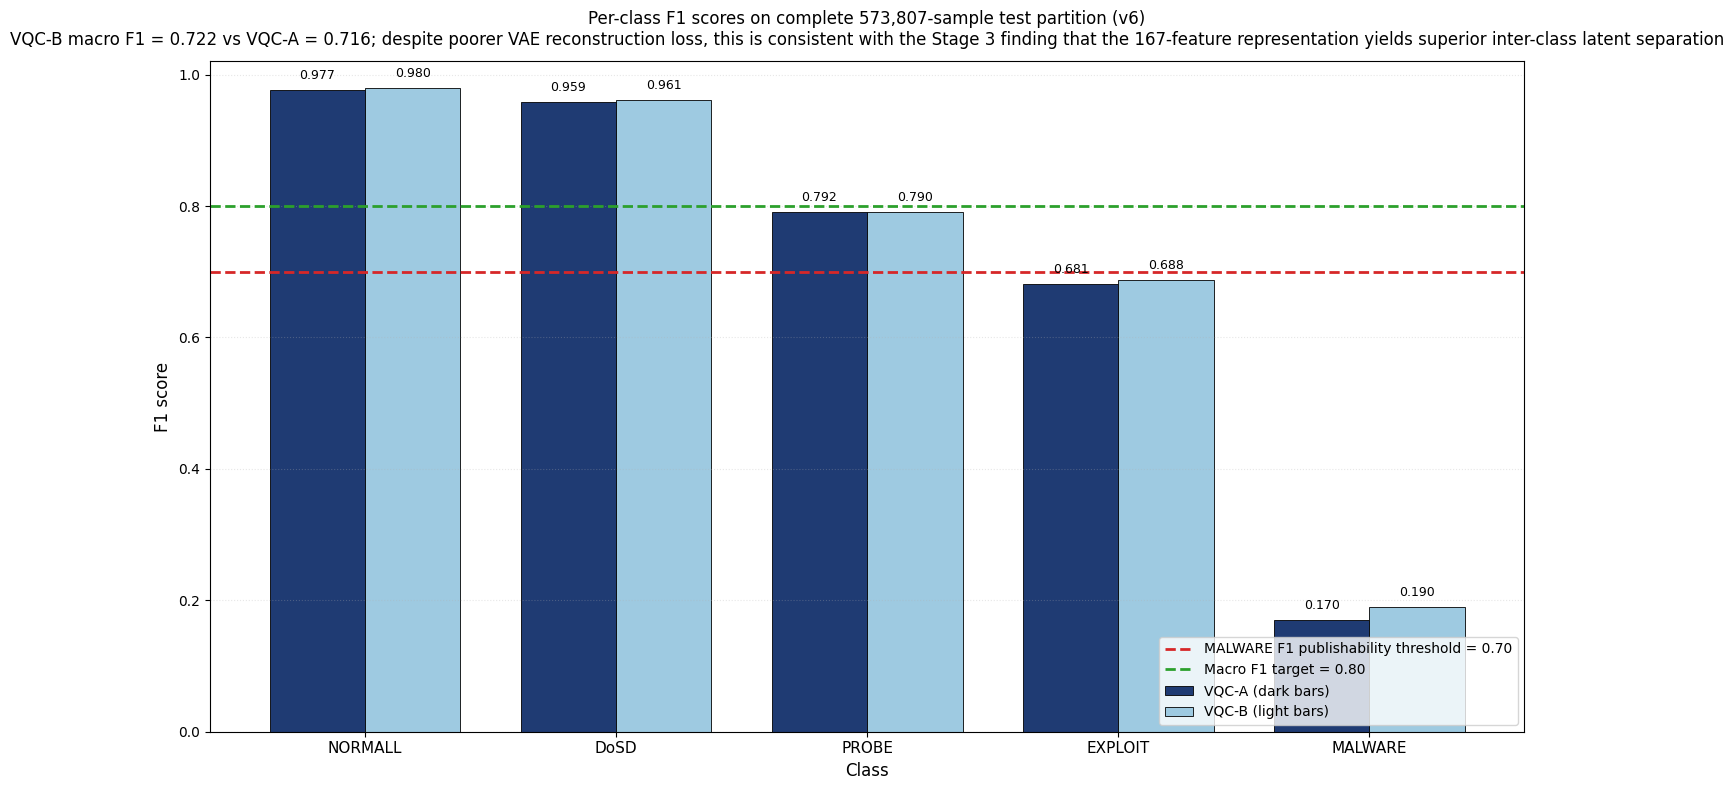

Saved plot: C:\Users\[USERNAME]\Desktop\MINOR PROJECT\artifacts\plots\vqc_ab_per_class_f1_publishability_v6.png
Macro F1 — VQC-A: 0.716, VQC-B: 0.722


In [1]:
# ============================================================
# Cell 16 — VQC-A vs VQC-B per-class F1 (full test set, Stage4-v6)
# ============================================================
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Resolved from Stage4-v6 final output (complete test partition, n=573,807).
CLASS_NAMES = ["NORMALL", "DoSD", "PROBE", "EXPLOIT", "MALWARE"]
F1_VQC_A = np.array([0.9771, 0.9590, 0.7916, 0.6815, 0.1696], dtype=float)
F1_VQC_B = np.array([0.9799, 0.9609, 0.7904, 0.6878, 0.1904], dtype=float)

MACRO_F1_VQC_A = 0.716
MACRO_F1_VQC_B = 0.722
N_TEST = 573_807
MALWARE_F1_PUBLISHABILITY_THRESHOLD = 0.70
MACRO_F1_TARGET = 0.80

x = np.arange(len(CLASS_NAMES))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 8))
bars_a = ax.bar(
    x - w / 2,
    F1_VQC_A,
    width=w,
    color="#1f3b73",
    edgecolor="black",
    linewidth=0.6,
    label="VQC-A (dark bars)",
)
bars_b = ax.bar(
    x + w / 2,
    F1_VQC_B,
    width=w,
    color="#9ecae1",
    edgecolor="black",
    linewidth=0.6,
    label="VQC-B (light bars)",
)

for bars in (bars_a, bars_b):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.012,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.axhline(
    MALWARE_F1_PUBLISHABILITY_THRESHOLD,
    color="#d62728",
    linestyle="--",
    linewidth=2.0,
    label=f"MALWARE F1 publishability threshold = {MALWARE_F1_PUBLISHABILITY_THRESHOLD:.2f}",
)
ax.axhline(
    MACRO_F1_TARGET,
    color="#2ca02c",
    linestyle="--",
    linewidth=2.0,
    label=f"Macro F1 target = {MACRO_F1_TARGET:.2f}",
)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0.0, 1.02)
ax.set_ylabel("F1 score", fontsize=12)
ax.set_xlabel("Class", fontsize=12)
ax.grid(axis="y", linestyle=":", alpha=0.30)

ax.set_title(
    "Per-class F1 scores on complete 573,807-sample test partition (v6)\n"
    "VQC-B macro F1 = 0.722 vs VQC-A = 0.716; despite poorer VAE reconstruction loss, "
    "this is consistent with the Stage 3 finding that the 167-feature representation yields "
    "superior inter-class latent separation",
    fontsize=12,
    pad=12,
)

ax.legend(loc="lower right", fontsize=10, frameon=True)
plt.tight_layout()

cwd = Path(os.getcwd()).resolve()
if (cwd / "artifacts").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "artifacts").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

out_dir = PROJECT_ROOT / "artifacts" / "plots"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "vqc_ab_per_class_f1_publishability_v6.png"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved plot: {out_path}")
print(f"Macro F1 — VQC-A: {MACRO_F1_VQC_A:.3f}, VQC-B: {MACRO_F1_VQC_B:.3f}")

C:\Users\[USERNAME]\AppData\Local\Temp\ipykernel_18056\3060116093.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.985])


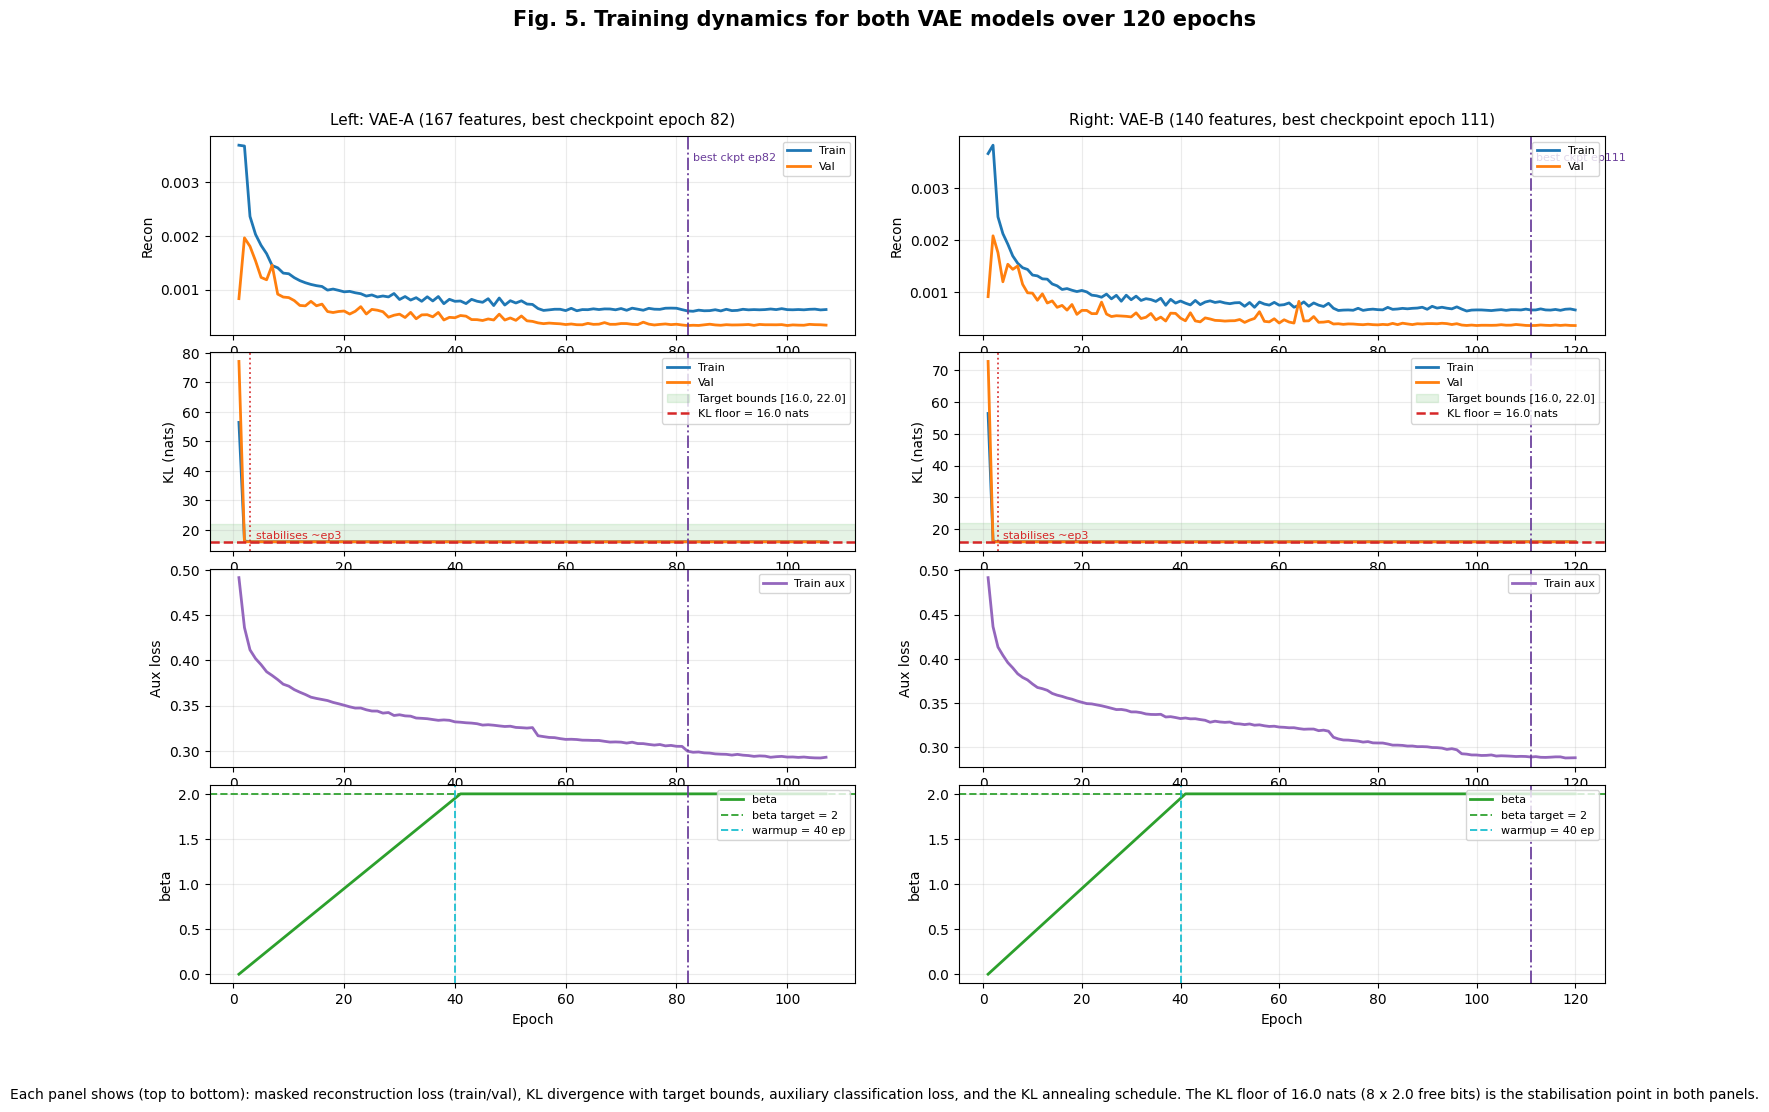

Saved plot: C:\Users\[USERNAME]\Desktop\MINOR PROJECT\artifacts\plots\fig5_vae_training_dynamics_120.png


In [2]:
# ============================================================
# Cell 17 - Fig. 5: Training dynamics for both VAE models (120 epochs)
# ============================================================
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root whether this notebook is run from project root or from VQC/.
cwd = Path(os.getcwd()).resolve()
if (cwd / "VAE").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "VAE").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate project root containing VAE/ directory.")

MODELS = [
    {
        "key": "VAE-A",
        "subtitle": "Left: VAE-A (167 features, best checkpoint epoch 82)",
        "history_path": PROJECT_ROOT / "VAE" / "vae_a_output_16" / "vae_a_training_history.json",
        "config_path": PROJECT_ROOT / "VAE" / "vae_a_output_16" / "vae_a_config.json",
    },
    {
        "key": "VAE-B",
        "subtitle": "Right: VAE-B (140 features, best checkpoint epoch 111)",
        "history_path": PROJECT_ROOT / "VAE" / "vae_b_output_16" / "vae_b_training_history.json",
        "config_path": PROJECT_ROOT / "VAE" / "vae_b_output_16" / "vae_b_config.json",
    },
]

MAX_EPOCHS = 120
KL_FLOOR = 16.0  # 8 x 2.0 free bits
KL_TARGET_MAX = 22.0


def load_history(path: Path) -> pd.DataFrame:
    with path.open("r", encoding="utf-8") as f:
        rows = json.load(f)
    return pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)


def expand_epochs(df: pd.DataFrame, max_epochs: int) -> pd.DataFrame:
    full = pd.DataFrame({"epoch": np.arange(1, max_epochs + 1, dtype=int)})
    return full.merge(df, on="epoch", how="left")


fig = plt.figure(figsize=(18, 11))
outer = fig.add_gridspec(1, 2, wspace=0.16)

for panel_idx, model in enumerate(MODELS):
    with model["config_path"].open("r", encoding="utf-8") as f:
        cfg = json.load(f)

    hist = expand_epochs(load_history(model["history_path"]), MAX_EPOCHS)
    epochs = hist["epoch"].to_numpy()
    best_epoch = int(cfg.get("best_epoch", 0))
    warmup_epochs = int(cfg.get("warmup_epochs", 40))
    beta_target = float(cfg.get("beta_target", 2.0))

    inner = outer[panel_idx].subgridspec(4, 1, hspace=0.09)
    ax_recon = fig.add_subplot(inner[0, 0])
    ax_kl = fig.add_subplot(inner[1, 0], sharex=ax_recon)
    ax_aux = fig.add_subplot(inner[2, 0], sharex=ax_recon)
    ax_beta = fig.add_subplot(inner[3, 0], sharex=ax_recon)

    # Top: masked reconstruction loss (train/val)
    ax_recon.plot(epochs, hist["tr_recon"], color="#1f77b4", lw=2.0, label="Train")
    ax_recon.plot(epochs, hist["val_recon"], color="#ff7f0e", lw=2.0, label="Val")
    ax_recon.set_ylabel("Recon")
    ax_recon.grid(alpha=0.25)
    ax_recon.legend(loc="upper right", fontsize=8)

    # 2nd: KL divergence with target bounds and floor line.
    ax_kl.plot(epochs, hist["tr_kl"], color="#1f77b4", lw=2.0, label="Train")
    ax_kl.plot(epochs, hist["val_kl"], color="#ff7f0e", lw=2.0, label="Val")
    ax_kl.axhspan(KL_FLOOR, KL_TARGET_MAX, color="#2ca02c", alpha=0.12,
                  label=f"Target bounds [{KL_FLOOR:.1f}, {KL_TARGET_MAX:.1f}]")
    ax_kl.axhline(KL_FLOOR, color="#d62728", ls="--", lw=1.8,
                  label=f"KL floor = {KL_FLOOR:.1f} nats")
    ax_kl.set_ylabel("KL (nats)")
    ax_kl.grid(alpha=0.25)
    ax_kl.legend(loc="upper right", fontsize=8)

    # Mark KL stabilization point as the first epoch where train KL is essentially at floor.
    tr_kl = pd.to_numeric(hist["tr_kl"], errors="coerce").to_numpy(dtype=float)
    stable_idx = np.where(np.isfinite(tr_kl) & (np.abs(tr_kl - KL_FLOOR) <= 0.05))[0]
    if len(stable_idx) > 0:
        stable_epoch = int(epochs[stable_idx[0]])
        ax_kl.axvline(stable_epoch, color="#d62728", ls=":", lw=1.3, alpha=0.9)
        ax_kl.text(stable_epoch + 1, KL_FLOOR + 0.9, f"stabilises ~ep{stable_epoch}",
                   color="#d62728", fontsize=8)

    # 3rd: auxiliary classification loss (train).
    ax_aux.plot(epochs, hist["tr_aux"], color="#9467bd", lw=2.0, label="Train aux")
    ax_aux.set_ylabel("Aux loss")
    ax_aux.grid(alpha=0.25)
    ax_aux.legend(loc="upper right", fontsize=8)

    # Bottom: KL annealing schedule.
    ax_beta.plot(epochs, hist["beta"], color="#2ca02c", lw=2.0, label="beta")
    ax_beta.axhline(beta_target, color="#2ca02c", ls="--", lw=1.4, alpha=0.9,
                    label=f"beta target = {beta_target:g}")
    ax_beta.axvline(warmup_epochs, color="#17becf", ls="--", lw=1.4, alpha=0.9,
                    label=f"warmup = {warmup_epochs} ep")
    ax_beta.set_ylabel("beta")
    ax_beta.set_xlabel("Epoch")
    ax_beta.grid(alpha=0.25)
    ax_beta.legend(loc="upper right", fontsize=8)

    # Highlight best checkpoint in all four subplots.
    if best_epoch > 0:
        for ax in (ax_recon, ax_kl, ax_aux, ax_beta):
            ax.axvline(best_epoch, color="#6a3d9a", ls="-.", lw=1.4, alpha=0.9)
        ax_recon.text(best_epoch + 1, np.nanmax(hist["tr_recon"]) * 0.92,
                      f"best ckpt ep{best_epoch}", color="#6a3d9a", fontsize=8)

    ax_recon.set_title(model["subtitle"], fontsize=11, pad=8)

fig.suptitle("Fig. 5. Training dynamics for both VAE models over 120 epochs", fontsize=15, fontweight="bold", y=0.995)
fig.text(
    0.5,
    0.002,
    "Each panel shows (top to bottom): masked reconstruction loss (train/val), KL divergence with target bounds, "
    "auxiliary classification loss, and the KL annealing schedule. The KL floor of 16.0 nats (8 x 2.0 free bits) "
    "is the stabilisation point in both panels.",
    ha="center",
    va="bottom",
    fontsize=10,
)

plt.tight_layout(rect=[0, 0.04, 1, 0.985])

out_dir = PROJECT_ROOT / "artifacts" / "plots"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "fig5_vae_training_dynamics_120.png"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved plot: {out_path}")